# Global and Local CLAHE

In [8]:
import os
from constants import PROJECT_ROOT, GENERAL_IMAGES_DIR
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Image shape: (1600, 1067)


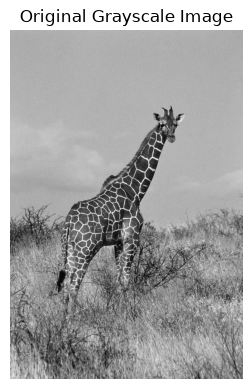

In [9]:
# Loading img, converting to grayscale and displaying

img_path = os.path.join(GENERAL_IMAGES_DIR, "giraffe_kenya.png")
img_color = Image.open(img_path).convert("RGB")
gray_img = np.array(img_color.convert("L"), dtype=np.uint8)

print("Image shape:", gray_img.shape)

plt.figure(figsize=(3, 9))
plt.imshow(gray_img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

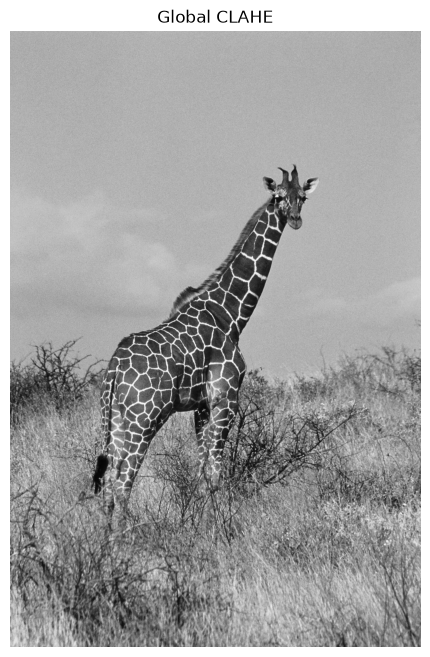

In [10]:
# writing Global CLAHE function

def compute_tile_mapping(tile, clip_limit, n_bins=256):
    """Build a clipped, redistributed histogram-equalization LUT for one tile."""
    hist, _ = np.histogram(tile.flatten(), bins=n_bins, range=(0, n_bins))

    #clip the  histogram at clip_limit and redistribute the excess uniformly
    excess = np.sum(np.maximum(hist - clip_limit, 0))
    hist_clipped = np.minimum(hist, clip_limit).astype(np.float64)
    hist_clipped += excess / n_bins

    # cumulative distribution -> intensity mapping
    cdf = np.cumsum(hist_clipped)
    cdf = cdf / cdf[-1] * (n_bins - 1)
    return cdf.astype(np.uint8)


def global_clahe(img, clip_limit=40):
    """CLAHE with the whole image treated as a single tile."""
    mapping = compute_tile_mapping(img, clip_limit)
    return mapping[img]


global_clahe_img = global_clahe(gray_img, clip_limit=40)

plt.figure(figsize=(6, 8))
plt.imshow(global_clahe_img, cmap="gray")
plt.title("Global CLAHE")
plt.axis("off")
plt.show()

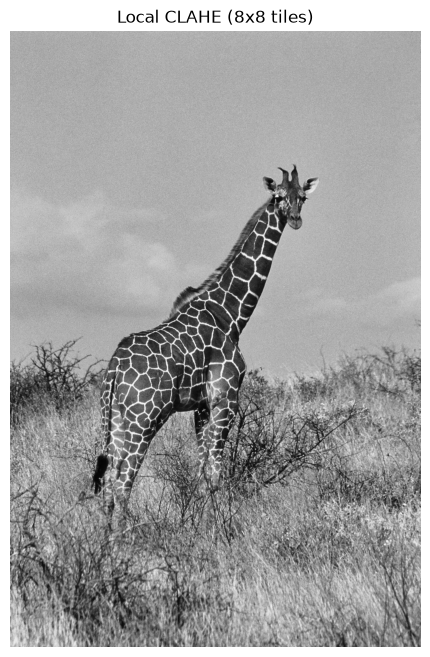

In [11]:
# local clahe
def local_clahe(img, clip_limit=40, grid_size=(8, 8), n_bins=256):
    h, w = img.shape
    gy, gx = grid_size

    # Tile size, padded so the image divides evenly into the grid
    tile_h = int(np.ceil(h / gy))
    tile_w = int(np.ceil(w / gx))
    pad_h = tile_h * gy - h
    pad_w = tile_w * gx - w
    padded = np.pad(img, ((0, pad_h), (0, pad_w)), mode="reflect")
    H, W = padded.shape

    # Build a LUT per tile
    mappings = np.zeros((gy, gx, n_bins), dtype=np.uint8)
    for i in range(gy):
        for j in range(gx):
            tile = padded[i * tile_h:(i + 1) * tile_h, j * tile_w:(j + 1) * tile_w]
            mappings[i, j] = compute_tile_mapping(tile, clip_limit, n_bins)

    # Tile centers, used as interpolation anchor points
    centers_y = (np.arange(gy) + 0.5) * tile_h
    centers_x = (np.arange(gx) + 0.5) * tile_w
    row_bounds = np.concatenate(([0], centers_y, [H])).astype(np.float64)
    col_bounds = np.concatenate(([0], centers_x, [W])).astype(np.float64)

    out = np.zeros_like(padded, dtype=np.float64)

    # Process one "band" between tile centers at a time (vectorized within each band)
    for bi in range(gy + 1):
        i0, i1 = np.clip(bi - 1, 0, gy - 1), np.clip(bi, 0, gy - 1)
        y0, y1 = int(row_bounds[bi]), int(row_bounds[bi + 1])
        if y1 <= y0:
            continue
        ys = np.arange(y0, y1)
        wy = np.zeros(len(ys)) if i0 == i1 else (ys - centers_y[i0]) / (centers_y[i1] - centers_y[i0])

        for bj in range(gx + 1):
            j0, j1 = np.clip(bj - 1, 0, gx - 1), np.clip(bj, 0, gx - 1)
            x0, x1 = int(col_bounds[bj]), int(col_bounds[bj + 1])
            if x1 <= x0:
                continue
            xs = np.arange(x0, x1)
            wx = np.zeros(len(xs)) if j0 == j1 else (xs - centers_x[j0]) / (centers_x[j1] - centers_x[j0])

            block = padded[y0:y1, x0:x1]
            m00, m01 = mappings[i0, j0][block], mappings[i0, j1][block]
            m10, m11 = mappings[i1, j0][block], mappings[i1, j1][block]

            WY, WX = wy[:, None], wx[None, :]
            out[y0:y1, x0:x1] = ((1 - WY) * (1 - WX) * m00 + (1 - WY) * WX * m01
                                 + WY * (1 - WX) * m10 + WY * WX * m11)

    return np.clip(out[:h, :w], 0, 255).astype(np.uint8)


local_clahe_img = local_clahe(gray_img, clip_limit=40, grid_size=(8, 8))

plt.figure(figsize=(6, 8))
plt.imshow(local_clahe_img, cmap="gray")
plt.title("Local CLAHE (8x8 tiles)")
plt.axis("off")
plt.show()

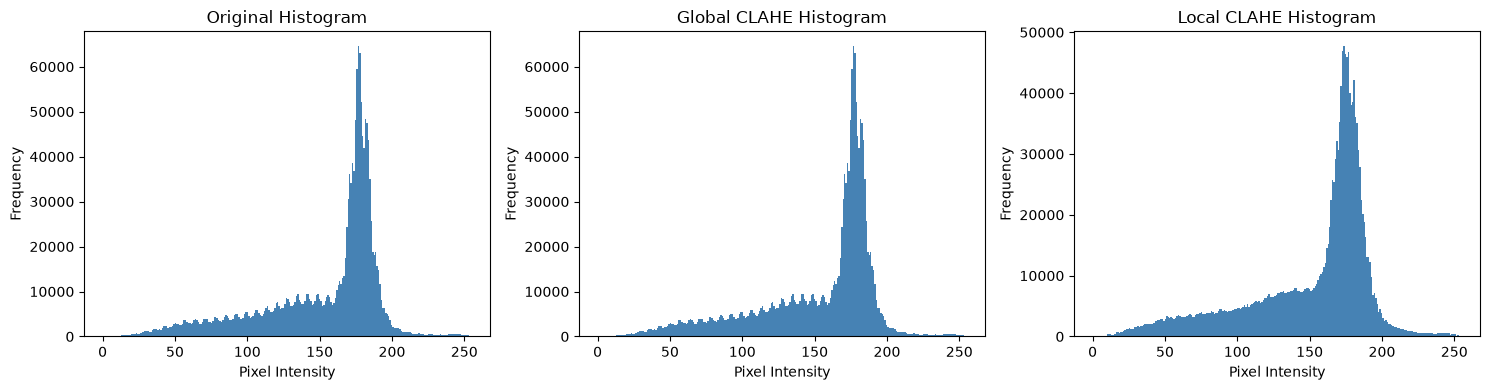

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, image, title in zip(
        axes,
        [gray_img, global_clahe_img, local_clahe_img],
        ["Original", "Global CLAHE", "Local CLAHE"]
):
    ax.hist(image.flatten(), bins=256, range=(0, 255), color="steelblue")
    ax.set_title(f"{title} Histogram")
    ax.set_xlabel("Pixel Intensity")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

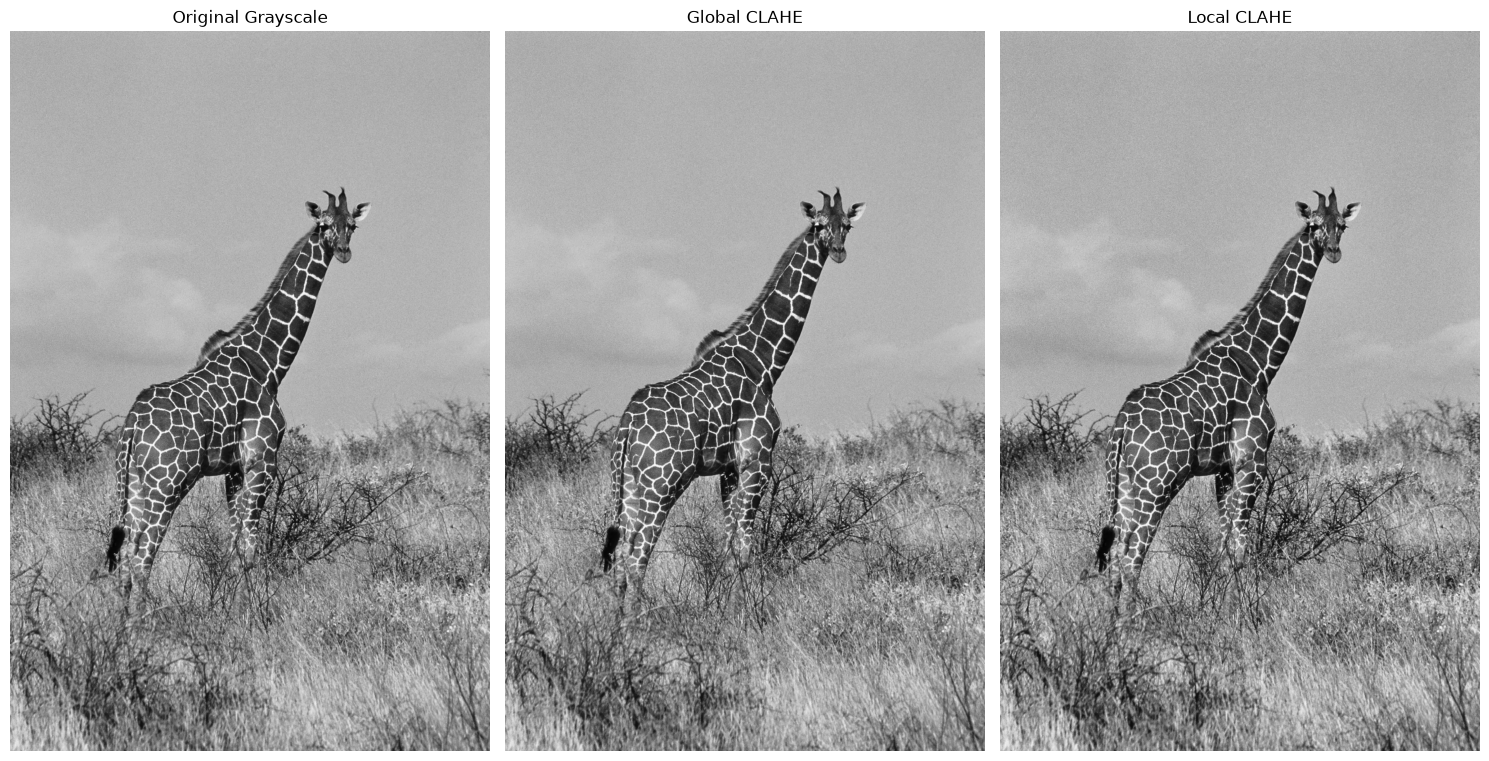

In [13]:
# final comparison

fig, axes = plt.subplots(1, 3, figsize=(15, 8))

for ax, image, title in zip(
        axes,
        [gray_img, global_clahe_img, local_clahe_img],
        ["Original Grayscale", "Global CLAHE", "Local CLAHE"]
):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()